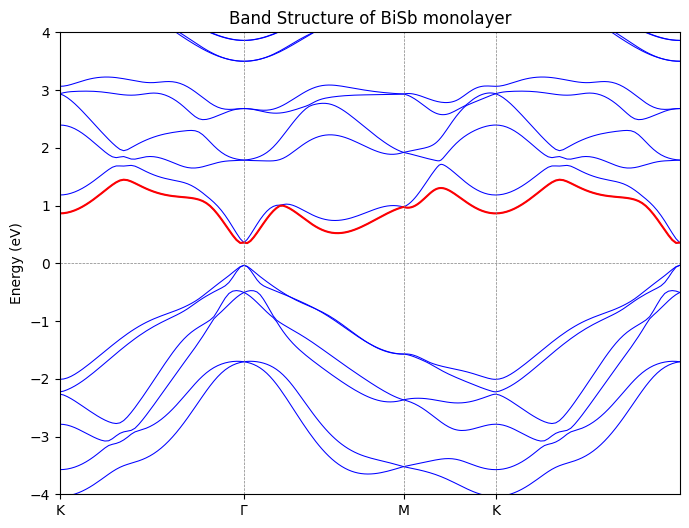

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data_band = np.loadtxt("REFORMATTED_BAND.dat")

k = data_band[:,0]
E = data_band[:,1:]

high_symmetry_points = [0, 0.982, 1.833, 2.324, 3.306]
labels = ['K', '$\Gamma$', 'M', 'K', '$\Gamma$']

plt.figure(figsize=(8, 6))
for i in range(E.shape[1]):
    plt.plot(k, E[:, i], color='blue',lw=0.75)
#plt.plot(k, E[:, 20], color='red', lw=1.5, label='Valence Band')
for i in range(len(high_symmetry_points)):
    plt.axvline(x=high_symmetry_points[i], color='gray', linestyle='--', lw=0.5)

plt.axhline(y=0, color='gray', linestyle='--', lw=0.5)    

plt.xticks(high_symmetry_points, labels)
plt.ylabel('Energy (eV)')
plt.title('Band Structure of BiSb monolayer')
plt.xlim(min(k), max(k))
plt.ylim(-5, 5)
plt.show() 

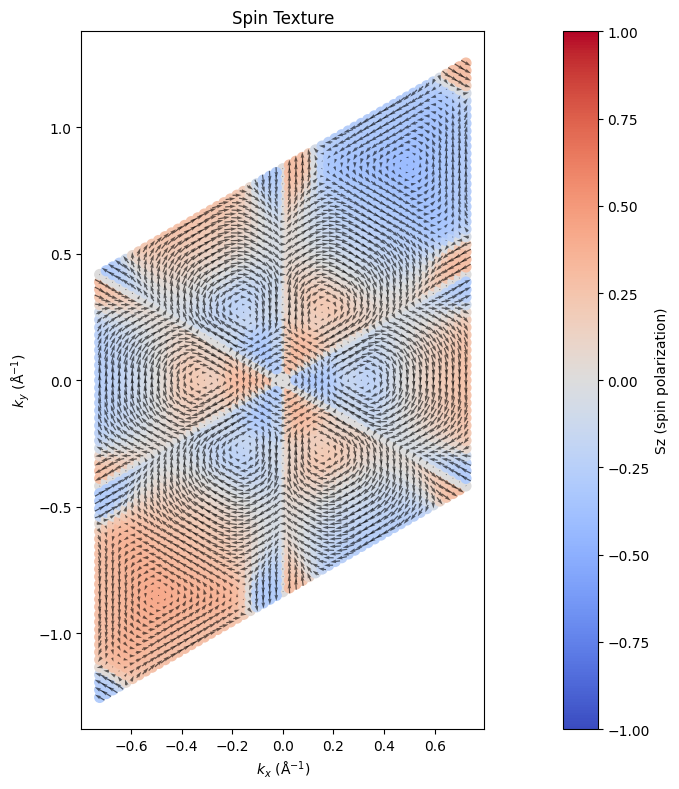

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

data_spin = np.loadtxt(
    "tight_SPIN_TEXTURE_GAMMA.dat",
    comments="#",
    usecols=(0, 1, 3, 4, 5),
)
kx = data_spin[:, 0]
ky = data_spin[:, 1]
Sx = data_spin[:, 2]
Sy = data_spin[:, 3]
Sz = data_spin[:, 4]

fig, ax = plt.subplots(figsize=(16, 8))

# Background: scatter colored by Sz
norm = Normalize(vmin=-1, vmax=1)
sc = ax.scatter(kx, ky, c=Sz, cmap="coolwarm", norm=norm, s=50, zorder=1)
fig.colorbar(sc, ax=ax, label="Sz (spin polarization)")

# Foreground: quiver arrows showing in-plane spin (Sx, Sy)
ax.quiver(kx, ky, Sx, Sy,
          pivot="mid",
          scale=8,          # lower = longer arrows; tune to your grid
          scale_units="xy",
          width=0.003,
          color="black",
          alpha=0.6,
          zorder=2)

ax.set_xlabel(r"$k_x$ (Å$^{-1}$)")
ax.set_ylabel(r"$k_y$ (Å$^{-1}$)")
ax.set_title("Spin Texture")
ax.set_aspect("equal")

plt.tight_layout()
#plt.savefig("spin_texture.png", dpi=150, bbox_inches="tight")
plt.show()

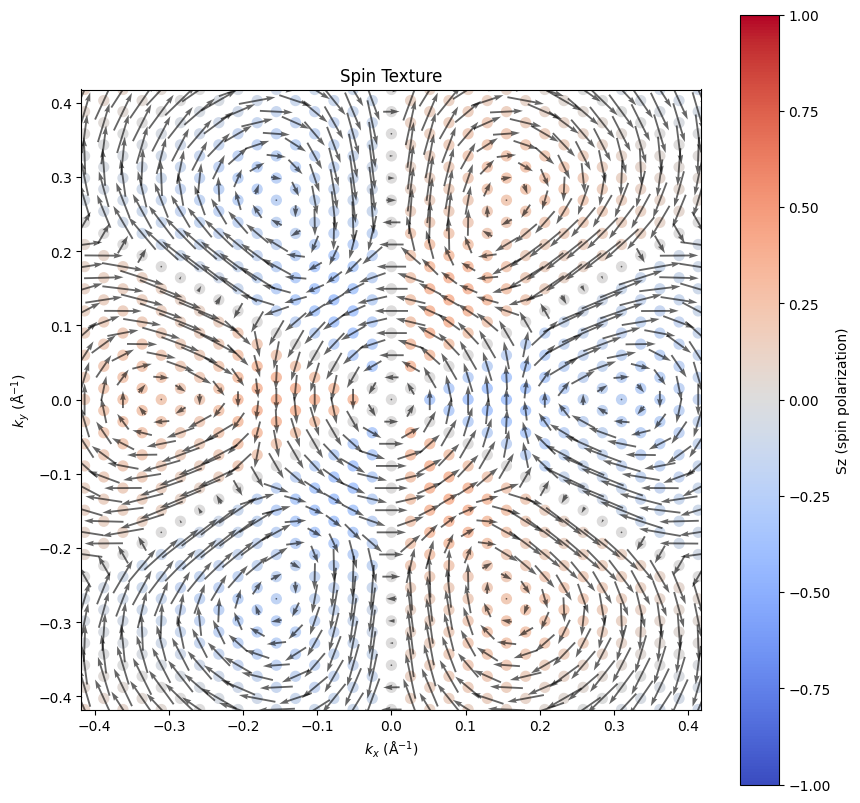

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

data_spin = np.loadtxt(
    "tight_SPIN_TEXTURE_GAMMA.dat",
    comments="#",
    usecols=(0, 1, 3, 4, 5),
)
kx = data_spin[:, 0]
ky = data_spin[:, 1]
Sx = data_spin[:, 2]
Sy = data_spin[:, 3]
Sz = data_spin[:, 4]

# ── Crop to the largest square fully covered by data ─────────────────────────
kx_unique = np.unique(kx)
ky_unique = np.unique(ky)

# For each ky row, find the kx extent; take the tightest (inner square)
kx_min_per_ky = [kx[ky == y].min() for y in ky_unique]
kx_max_per_ky = [kx[ky == y].max() for y in ky_unique]
kx_lo = np.max(kx_min_per_ky)
kx_hi = np.min(kx_max_per_ky)

# For each kx column, find the ky extent; take the tightest
ky_min_per_kx = [ky[kx == x].min() for x in kx_unique]
ky_max_per_kx = [ky[kx == x].max() for x in kx_unique]
ky_lo = np.max(ky_min_per_kx)
ky_hi = np.min(ky_max_per_kx)

# Use the tightest bound across both axes to guarantee no empty corners
k_sq = min(abs(kx_lo), abs(kx_hi), abs(ky_lo), abs(ky_hi))

mask = (np.abs(kx) <= k_sq) & (np.abs(ky) <= k_sq)

kx_p, ky_p = kx[mask], ky[mask]
Sx_p, Sy_p, Sz_p = Sx[mask], Sy[mask], Sz[mask]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))

norm = Normalize(vmin=-1, vmax=1)
sc = ax.scatter(kx_p, ky_p, c=Sz_p, cmap="coolwarm", norm=norm, s=50, zorder=1)
fig.colorbar(sc, ax=ax, label="Sz (spin polarization)")

ax.quiver(kx_p, ky_p, Sx_p, Sy_p,
          pivot="mid",
          scale=7,
          scale_units="xy",
          width=0.003,
          color="black",
          alpha=0.6,
          zorder=2)

ax.set_xlim(-k_sq, k_sq)
ax.set_ylim(-k_sq, k_sq)
ax.set_xlabel(r"$k_x$ (Å$^{-1}$)")
ax.set_ylabel(r"$k_y$ (Å$^{-1}$)")
ax.set_title("Spin Texture")
ax.set_aspect("equal")


#plt.savefig("spin_texture.png", dpi=150, bbox_inches="tight")
plt.show()


C:\Users\furka\AppData\Local\Temp\ipykernel_23468\890584428.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(r"PBAND_Bi_SOC.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)


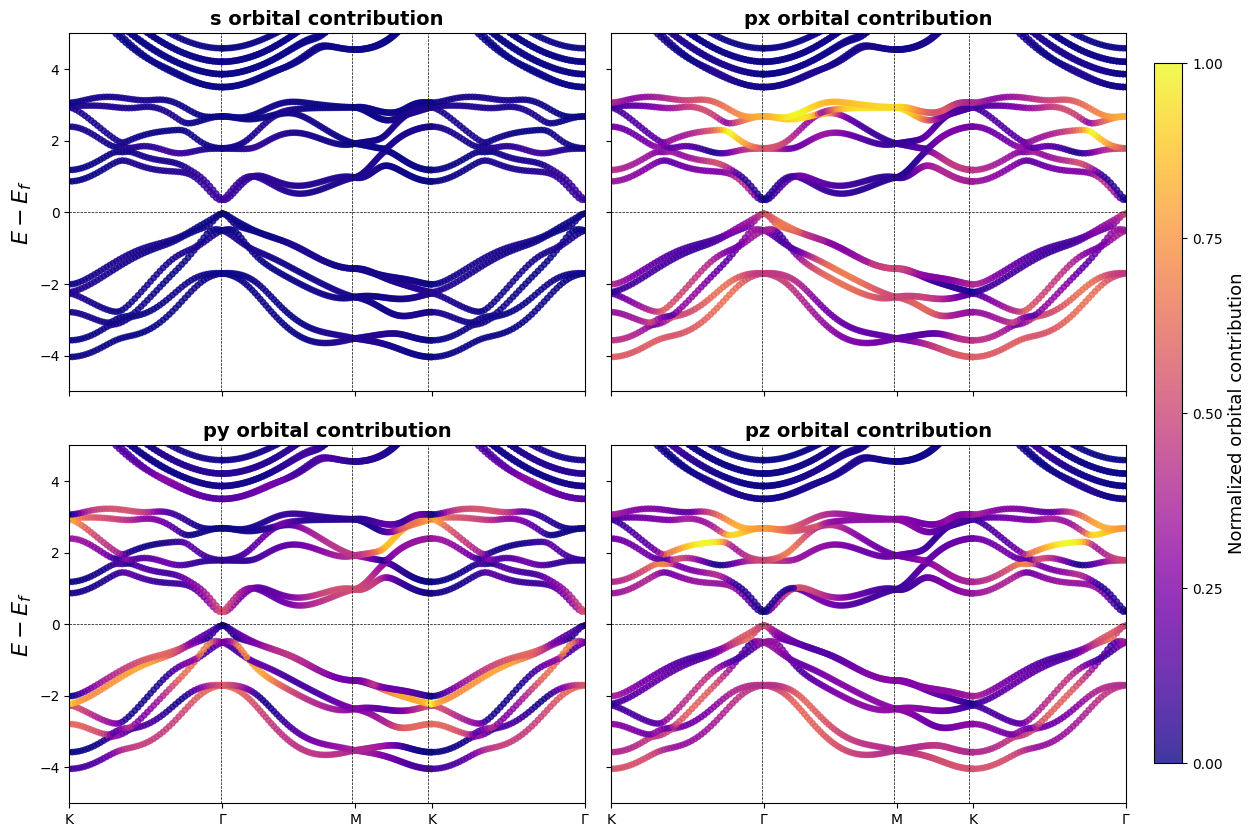

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv(r"PBAND_Bi_SOC.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)

k = np.array(data[0])
e = np.array(data[1])

# Extract raw orbital contribution values
s_vals  = data[2].values.astype(float)
px_vals = data[3].values.astype(float)
py_vals = data[4].values.astype(float)
pz_vals = data[5].values.astype(float)

# --- Normalize each orbital INDEPENDENTLY to [0, 1] ---
def local_norm(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

s_norm  = local_norm(s_vals)
px_norm = local_norm(px_vals)
py_norm = local_norm(py_vals)
pz_norm = local_norm(pz_vals)

orbitals = [s_norm, px_norm, py_norm, pz_norm]
names    = ['s', 'px', 'py', 'pz']
cmap     = 'plasma'

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
fig.subplots_adjust(right=0.88, hspace=0.15, wspace=0.05)
axes = axes.flatten()

last_scatter = None

for idx, (orbital, name) in enumerate(zip(orbitals, names)):
    ax = axes[idx]

    scatter = ax.scatter(
        k, e,
        c=orbital,
        s=15, cmap=cmap, alpha=0.8,
        vmin=0, vmax=1
    )
    last_scatter = scatter

    ax.set_title(f'{name} orbital contribution', fontsize=14, fontweight='bold')
    ax.set_ylim(-5, 5)
    ax.set_xlim(min(k), max(k))

    ax.axhline(0,     ls='--', lw=0.5, color='black')
    ax.axvline(0.972, ls='--', lw=0.5, color='black')
    ax.axvline(1.814, ls='--', lw=0.5, color='black')
    ax.axvline(2.300, ls='--', lw=0.5, color='black')

    if idx >= 2:
        ax.set_xticks([0, 0.982, 1.833, 2.324, 3.306])
        ax.set_xticklabels(['K', r'$\Gamma$', 'M', 'K', r'$\Gamma$'])

    if idx % 2 == 0:
        ax.set_ylabel(r'$E-E_f$', fontsize=16)

# --- Single colorbar, ticks just show 0 to 1 ---
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(last_scatter, cax=cbar_ax)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(['0.00', '0.25', '0.50', '0.75', '1.00'])
cbar.set_label('Normalized orbital contribution', fontsize=13)
cbar.ax.tick_params(labelsize=10)

plt.show()

C:\Users\furka\AppData\Local\Temp\ipykernel_23468\1634794093.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_bi = pd.read_csv(r"PBAND_Bi_SOC.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)
C:\Users\furka\AppData\Local\Temp\ipykernel_23468\1634794093.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_sb = pd.read_csv(r"PBAND_Sb_SOC.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)


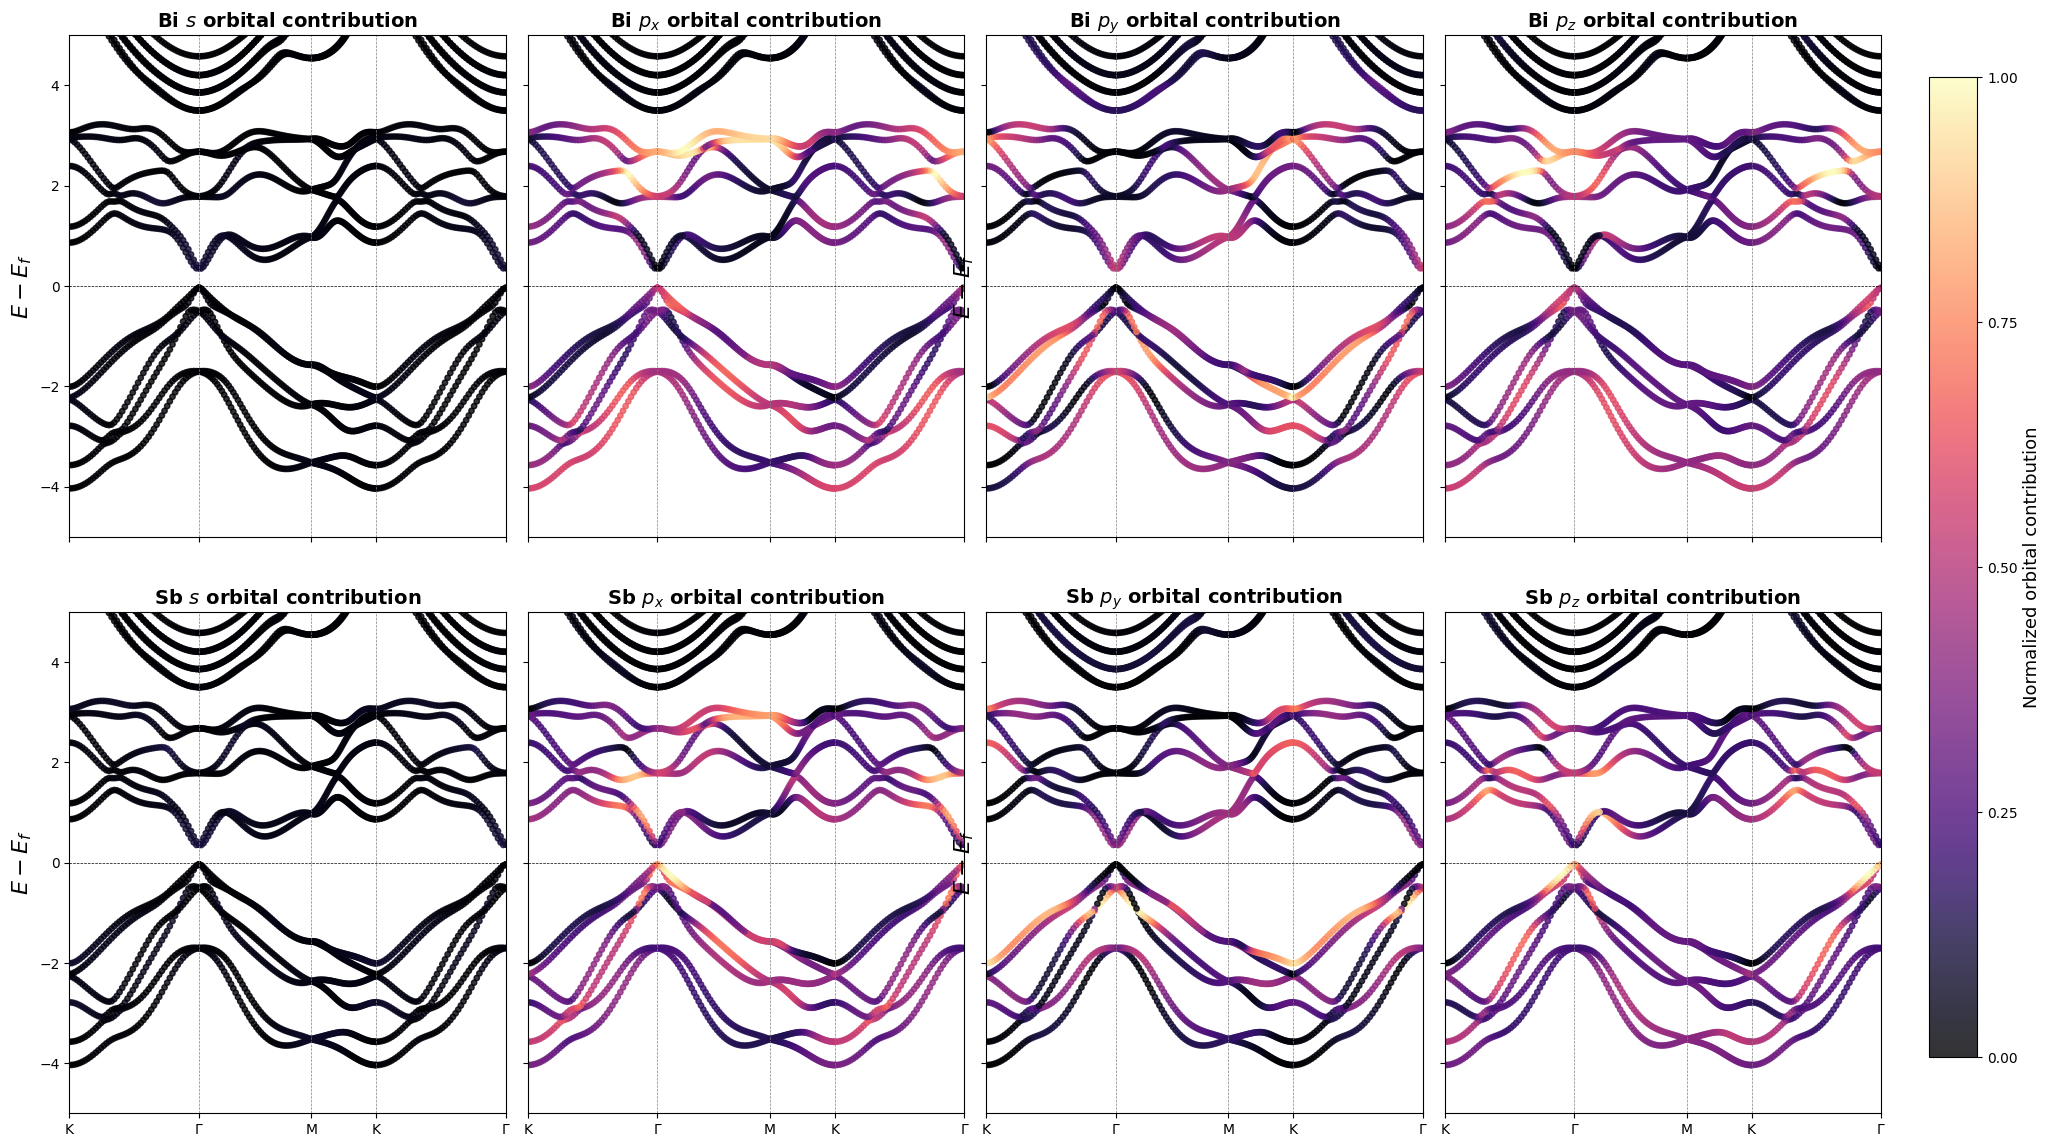

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- Load data for both atoms ---
data_bi = pd.read_csv(r"PBAND_Bi_SOC.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)
data_sb = pd.read_csv(r"PBAND_Sb_SOC.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)

k = np.array(data_bi[0])
e = np.array(data_bi[1])

# --- Extract raw values ---
bi_vals = [data_bi[i].values.astype(float) for i in range(2, 6)]  # s, px, py, pz
sb_vals = [data_sb[i].values.astype(float) for i in range(2, 6)]

# --- Normalize each orbital INDEPENDENTLY to [0, 1] ---
def local_norm(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

bi_norms = [local_norm(v) for v in bi_vals]
sb_norms = [local_norm(v) for v in sb_vals]


orbitals = [bi_norms[0],bi_norms[1], bi_norms[2], bi_norms[3],
            sb_norms[0],sb_norms[1], sb_norms[2], sb_norms[3]] 

names = ['Bi $s$', 'Bi $p_x$', 'Bi $p_y$', 'Bi $p_z$',
         'Sb $s$',  'Sb $p_x$', 'Sb $p_y$', 'Sb $p_z$']

cmap     = 'magma'

high_symmetry_points = [0, 0.982, 1.833, 2.324, 3.306]
high_symmetry_labels = ['K', r'$\Gamma$', 'M', 'K', r'$\Gamma$']

fig, axes = plt.subplots(2, 4, figsize=(24, 14), sharex=True, sharey=True)
fig.subplots_adjust(right=0.88, hspace=0.15, wspace=0.05)
axes = axes.flatten()

last_scatter = None

for idx, (orbital, name) in enumerate(zip(orbitals, names)):
    ax = axes[idx]

    scatter = ax.scatter(
        k, e,
        c=orbital,
        s=15, cmap=cmap, alpha=0.8,
        vmin=0, vmax=1
    )
    last_scatter = scatter

    ax.set_title(f'{name} orbital contribution', fontsize=14, fontweight='bold')
    ax.set_ylim(-5, 5)
    ax.set_xlim(min(k), max(k))

    for x in high_symmetry_points:
        ax.axvline(x=x, color='gray', linestyle='--', lw=0.5)
    ax.axhline(0, ls='--', lw=0.5, color='black')

    # x-axis tick labels for all rows (since they share x-axis)
    ax.set_xticks(high_symmetry_points)
    ax.set_xticklabels(high_symmetry_labels)

    # y-axis label only on left column
    if idx % 2 == 0:
        ax.set_ylabel(r'$E-E_f$', fontsize=16)

# --- Single global colorbar on the right ---
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(last_scatter, cax=cbar_ax)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(['0.00', '0.25', '0.50', '0.75', '1.00'])
cbar.set_label('Normalized orbital contribution', fontsize=13)
cbar.ax.tick_params(labelsize=10)

plt.show()